# UK Biobank — Academic Impact: the assembled panels

**What this notebook is.** The one place analysis 03's figures are *selected* and
*assembled*, on the model of
[`04_non_academic_99_all.ipynb`](04_non_academic_99_all.ipynb). The two source notebooks
stay as they are — they are where the data work and the diagnostics live — and this
notebook re-draws the charts that made the cut into one main-paper panel and two
supplementary panels.

| source notebook | charts | arm |
|---|---|---|
| [`03_academic_impact_01_for_analysis.ipynb`](03_academic_impact_01_for_analysis.ipynb) | 11 | volume, activity index, citation impact, quality bands, growth — by **field** |
| [`03_academic_impact_02_citation.ipynb`](03_academic_impact_02_citation.ipynb) | 3 | entry cohorts, impact portfolios, influence fingerprint — by **author** |

## The argument the figures make

Analysis 01 owns UK Biobank's *output*. This one owns its **position relative to the rest
of the literature**, which is the only thing the two-arm design can say and nothing else
in the project can. Every panel is a ratio against the whole database:

> where UK Biobank's work **lands** against how much of it there is (A) · what it is
> disproportionately **about** (B) · how much of each field's **best** work is its (C) ·
> and how its footprint splits at each field's own bars, field by field (D–K).

**Publication window: 2013–2025 inclusive**, for both UK Biobank and the comparison
literature. Citation references unavailable in early years are reported as unmeasured.
UK Biobank accounts for a small share of the tagged literature. A *share* of a field is therefore small everywhere by
construction and mostly reproduces "which fields are big", which is why both of the
page's ranking panels are activity indexes rather than shares, and why none of the volume
charts made the cut.

## Re-drawn, not pasted

Same rule as 04 (D28). Every panel is re-drawn from the data through `draw_<name>(ax, D)`
functions in
[`data_analysis_03_academic_impact_panels.py`](../utils/data_analysis_03_academic_impact_panels.py),
into a figure this notebook has already sized, under one style section — never by pasting
saved images. **Nothing has to be on disk for that**, which is why §1 is an inventory and
not a gate: the field notebook inherits `save: false` and writes none of its 11 charts.

The palette is `shared_style.PALETTE_COLORS` — **the same seven named colours analysis 04
is drawn in** (D29), so the two figure families belong to one paper. Where a chart needs
more than seven categories or an ordered ramp, it is derived from those anchors rather
than reaching for a new hue.

## The selection

Decided with the project owner on **2026-09-09** against all 14 charts, and cut again on
**2026-09-10**. Unlike 04, this selection **does** discard: nine of the fourteen are in
neither the main figure nor the SI — including all three of the author arm's, which were
SI 3 until the second cut — and §3 records the reason per chart rather than leaving it
implicit.

| figure | panels | contents |
|---|---|---|
| **Main** | A–K | impact map (2×2) · activity index · top-decile share · the footprint cut twice, a 2×4 field block spanning the page, one letter per field |
| **SI 1** | A–B | the impact map at 25 fields, every point labelled · those same 25 fields' top-decile share year by year |
| **SI 2** | A–B | growth, not size: rates, and the trajectories behind them |

## Naming

Per **D30**, the pages are named by the `01_growth` scheme —
`03_01_figure_01_…` for the main figure and `03_02_supplementary_figure_01_…` onwards for
the SI — not by the role-based scheme 04 originally used and has since been renamed off.

## 1. Setup

The style section is `03_academic_impact_99_all` — the seven-colour palette that
`shared_style.PALETTE_COLORS` names, dashed gridlines on both axes and both tick levels,
and `save: true` writing PDF and PNG, with PNG at 500 dpi into
`output/figures/data_analysis/03_academic_impact/`.

§1's inventory is **informational**. The author arm's three figures are on disk because
its notebook sets `save = True`; the field arm's eleven are not, because it inherits
`save: false`. Neither fact affects anything below — nothing here reads a saved figure,
and none of those three is drawn on this page any more (§3).

In [2]:
import sys
from pathlib import Path

# Anchor every path on the repo root regardless of where the notebook is launched from
# (repo root, src/, or src/data_analysis/). See shared_paths for the why.
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "src" / "utils").is_dir())
sys.path.insert(0, str(ROOT / "src"))
from utils import shared_paths as P
P.bootstrap()

# The panel module is edited while this notebook stays open; without autoreload a
# re-run of a figure cell silently reuses the function imported at kernel start.
%load_ext autoreload
%autoreload 2

import pandas as pd
from IPython.display import display

from utils.shared_style import PALETTE_COLORS, load_style
from utils import data_analysis_03_academic_impact_panels as NP

STYLE = load_style("03_academic_impact_99_all")

FIG_DIR = Path(STYLE["savedir"])
TABLE_DIR = P.OUTPUT_TABLES / "03_academic_impact"
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("palette :", ", ".join(f"{k}={v}" for k, v in PALETTE_COLORS.items()))
print("figures :", P.raw_path(FIG_DIR), "|", ", ".join(STYLE["formats"]),
      "at dpi", STYLE["dpi"])
print("tables  :", P.raw_path(TABLE_DIR))
print("grid    :", STYLE["grid_linestyle"], "on both axes, major and minor")

_on_disk = sorted({f.stem for f in FIG_DIR.glob("*.*")
                   if f.suffix.lower() in {".pdf", ".png"}})
print(f"\n{len(_on_disk)} figure stem(s) already under that directory "
      f"(informational — the assembly re-draws and reads none of them):")
for stem in _on_disk:
    print("   ", stem)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
palette : red=#E66859, cream=#FEE7BA, light_blue=#75BBD4, blue=#74ADD1, steel_blue=#416FA0, navy=#274668, green=#74D1AF
figures : output/figures/data_analysis/03_academic_impact | pdf, png at dpi 600
tables  : output/tables/03_academic_impact
grid    : -- on both axes, major and minor

6 figure stem(s) already under that directory (informational — the assembly re-draws and reads none of them):
    03_01_figure_01_academic_impact
    03_02_supplementary_figure_01_impact_map_full
    03_03_supplementary_figure_02_top_decile_share
    03_04_supplementary_figure_03_growth
    fig3a_author_entry_cohort_academic_impact_profile
    fig_author_influence_fingerprint_heatmap


## 2. Build the aggregates — once, from both arms

Roughly 20 seconds: `AI.build` loads the two count arms off the API pathway, then the
measured cut-off tables and the author arm's two written tables. Everything the panels
draw comes out of this one dict, so a figure cannot quietly read a different vintage of
the data than its neighbour.

**The author arm is read, not rebuilt.** Its tables come from
`03_academic_impact_02_citation.ipynb`, which is the notebook responsible for them;
rebuilding here would mean re-exploding 267,571 author slots out of the corpus parquet to
reproduce a file that already exists. The paper-level table is 62 MB and is read six
columns wide rather than twenty-four.

`assert_parameters_match()` then checks the loaded run against this module's constants —
they are copied from the field notebook's §2 rather than imported, because a notebook
cannot be imported, so the tripwire is what stops the two drifting.

In [3]:
D = NP.build_panel_data()
NP.assert_parameters_match(D)
print("\nparameters match the loaded run.")

loading both arms from data/analysis/academic_impact/for_counts_api (API pathway) …
loading for partials from /Users/valler/Python/RA/20_years_of_ukb/data/analysis/academic_impact/for_counts_api
  ukbb       1 partial(s), 613 rows, 113 fields, blank labels 0.0%
  background 1 partial(s), 3,762 rows, 171 fields, blank labels 0.0%
  !! only one arm carries n_frac, n_cit_frac, n_cit_docs_frac, n_fcr, n_fcr_frac, n_fcr_docs, n_fcr_docs_frac, n_recent, n_recent_frac, n_recent_docs, n_recent_docs_frac, n_mncs_frac, n_mncs_docs_frac, n_top10f_frac, n_top10f_docs_frac, n_top50f_frac, n_top50f_docs_frac — dropped, because the whole-database
     total for a one-armed measure is just that arm again. Everything below uses
     n_papers where it would have used n_frac.
  measures: n_papers, n_cit, n_cit_docs, n_mncs, n_mncs_docs, n_top10f, n_top10f_docs, n_top50f, n_top50f_docs
  citation weights: n_cit, n_top10f, n_top50f, n_mncs
  no relative ratio for n_cit — not normalised by publication year,

### What the two arms actually contain

Printed rather than remembered — these are the numbers the panels are drawn on, and they
are the rows to check against `doc/STATE.md` §2 before quoting anything from the figures.

In [4]:
print(f"analysis window      {NP.ANALYSIS_MIN}-{NP.ANALYSIS_MAX}   "
      f"(vocabulary: {D['SYSTEM']} {D['LEVEL']})")
print(f"UK Biobank's share   {D['ukbb_overall_share']:.3f}% of the whole database")
print(f"citation window      {D['CITE_WIN'][0]}-{D['CITE_WIN'][1]}   "
      f"headline {D['CITE_HEADLINE']}")
print(f"measured cut-offs    {int(D['CUTS'].thr10.notna().sum())} (year, field) cells")
print(f"authors              {len(D['author']['summary']):,} distinct\n")

print(f"UK Biobank's top {NP.TOP_N} fields — share, activity index, relative impact:\n")
_head = D["CITE_HEADLINE"][2:]
_rows = []
for code_, lab in zip(D["TOP_CODES"], D["TOP_LABELS"]):
    _rows.append({
        "field": lab,
        "ukbb_papers": int(D["ukbb"][(D["ukbb"].for_label == lab)
                                     & D["ukbb"].year.between(NP.ANALYSIS_MIN,
                                                              NP.ANALYSIS_MAX)]
                           [D["VALUE"]].sum()),
        "activity_x": round(D["ACTIVITY"].get(code_, float("nan")), 2),
        f"rci_{_head}": round(D["IMPACT"].loc[code_, f"rci_{_head}"], 2),
    })
display(pd.DataFrame(_rows))

print("author-entry cohort shares (%):")
display((100 * D["author"]["contrib_share"]).round(1))

analysis window      2015-2025   (vocabulary: Fields of Research (ANZSRC 2020) L4)
UK Biobank's share   0.044% of the whole database
citation window      2015-2025   headline n_mncs
measured cut-offs    213 (year, field) cells
authors              88,662 distinct

UK Biobank's top 8 fields — share, activity index, relative impact:



,field,ukbb_papers,activity_x,rci_mncs
0,Epidemiology,6256,12.00,1.80
1,Clinical Sciences,5458,0.86,2.83
2,Genetics,5321,6.20,2.72
3,Biological Psychology,2244,2.42,2.12
4,Cardiovascular Medicine and Haematology,1904,1.84,4.29
5,Public Health,1864,0.93,3.11
6,Oncology and Carcinogenesis,1359,0.74,1.62
7,Health Services and Systems,1207,0.32,3.04


author-entry cohort shares (%):


entry_cohort,2015–2017\nfoundational entrants,2018–2020\nexpansion entrants,2021–2023\nconsolidation entrants,2024–2025\nrecent entrants
Unique authors,5.0,19.6,35.8,39.6
Fractional paper credit,18.1,25.6,32.5,23.8
Fractional citation credit,42.8,32.8,20.1,4.3
Top-decile paper credit,24.4,28.3,31.7,15.6
First/last-author credit,18.5,26.5,32.7,22.3


## 3. The selection, on the record

One row per panel: which figure, which letter, and the caption line that goes under it —
plus the charts that are in **neither** figure, with the reason. Written to
`output/tables/03_academic_impact/panel_selection.csv` so the paper draft and this
notebook cannot disagree about which chart is panel D, or about why chart 6 is absent.

**Two debts this selection leaves owing**, both consequences of dropping the quality-band
SI and chart 6:

1. **Chart 9 is now a main-paper panel (D), so its cut-offs need a methods home.** §6.1 of
   the field notebook measures what "top decile" and "above the median" were worth in
   citations per (year, field) — 213 measured L4 cells, the decile landing at 7.30–10.00%
   and the median at 34.23–50.00%. The panel annotations carry the final year's pair, so
   the figure is partly self-documenting, but the full table belongs in the methods
   section as a **table**.
2. **Nothing now shows the impact result surviving the choice of measure.** That was
   chart 6's left panel. `n_mncs`, `n_top10f` and `n_top50f` rank the fields differently
   by construction. Cheapest mitigation: carry all three columns in SI 1's `IMPACT` table
   rather than the headline alone — which the table written below does.

In [5]:
rows = [{"figure": "03_01_figure_01_academic_impact", "panel": letter,
         "caption": caption}
        for letter, caption in NP.MAIN_CAPTION.items()]
_si_stems = {"impact_map": "03_02_supplementary_figure_01_impact_map_full",
             "top_decile": "03_03_supplementary_figure_02_top_decile_share",
             "growth": "03_04_supplementary_figure_03_growth"}
rows += [{"figure": _si_stems[section], "panel": letter, "caption": caption}
         for section, captions in NP.SI_CAPTIONS.items()
         for letter, caption in captions.items()]

# The charts in NEITHER figure. Recorded here so the reason survives the decision rather
# than living only in a chat log.
EXCLUDED = {
    "chart 1":  "whole-database trends with UK Biobank stacked in. The slice is invisible "
                "in 7 of 8 panels - true, and the point of the 0.044% fact, but it cannot "
                "carry a panel. 01_growth owns output.",
    "chart 2":  "UK Biobank papers per field and share of field. Volume, not position; "
                "01_growth owns it, and panel A divides the size out anyway.",
    "chart 3":  "annual growth speed, the first difference of chart 1. A diagnostic - the "
                "series is dominated by year-to-year sawtooth.",
    "chart 6":  "the measures-agree dot chart and impact over time. Dropped in favour of "
                "chart 7 as the single impact headline; the IMPACT table now has to carry "
                "the measure-robustness result numerically. See the note in section 3.",
    "chart 9a": "chart 9 against the cut-offs themselves on a second axis.",
    "chart 10": "the size of each field's top-decile pool and UK Biobank's share of it.",
    "sec 4.3":  "the marginal annual increase table (before vs after UKBB_YEAR).",
    "fig3a":    "author entry cohorts: share of authors, credit and top-decile credit by "
                "the year an author first published. Was SI 3A until 2026-09-10, when the "
                "author arm came out of this figure set - the page is the FIELD arm's "
                "argument, and a reader who wants the author result has "
                "03_academic_impact_02_citation.ipynb, which owns the tables either way.",
    "fig3b":    "the author portfolio map, 11,022 authors as output against "
                "field-normalised impact. Out with the rest of the author arm "
                "(2026-09-10); it was also the 8 MB svg that ended svg exports.",
    "fig3c":    "the author influence fingerprint, 25 named individuals by percentile "
                "rank. Out with the rest of the author arm (2026-09-10).",
}
rows += [{"figure": "(excluded)", "panel": chart, "caption": why}
         for chart, why in EXCLUDED.items()]

selection = pd.DataFrame(rows)
selection.to_csv(TABLE_DIR / "panel_selection.csv", index=False)
print(f"{len(NP.MAIN_CAPTION)} main panels + "
      f"{sum(len(c) for c in NP.SI_CAPTIONS.values())} SI panels + "
      f"{len(EXCLUDED)} excluded charts -> "
      f"{P.raw_path(TABLE_DIR / 'panel_selection.csv')}\n")
display(selection)

4 main panels + 4 SI panels + 10 excluded charts -> output/tables/03_academic_impact/panel_selection.csv



,figure,panel,caption
0,03_01_figure_01_academic_impact,A,Where UK Biobank concentrates against where th...
1,03_01_figure_01_academic_impact,B,"A's horizontal axis on its own, ranked: what U..."
2,03_01_figure_01_academic_impact,C,"A's vertical question over time, at the sharp ..."
3,03_01_figure_01_academic_impact,D-K,"The footprint cut twice, one lettered panel pe..."
4,03_02_supplementary_figure_01_impact_map_full,A,The impact map at UK Biobank's 25 largest fiel...
5,03_03_supplementary_figure_02_top_decile_share,A,Main-figure panel C undrawn-down: UK Biobank's...
6,03_04_supplementary_figure_03_growth,A,"Compound annual growth 2021–2025 by field, UK ..."
7,03_04_supplementary_figure_03_growth,B,The absolute trajectories those rates summaris...
8,(excluded),chart 1,whole-database trends with UK Biobank stacked ...
9,(excluded),chart 2,UK Biobank papers per field and share of field...


## 4. The main-paper panel

Three lettered panels on a three-column grid, over a block of eight more:

```text
+---------------------------+-----------+
|                           |     B     |   A     impact map        (2 rows x 2 cols)
|             A             +-----------+   B     activity index    (top right)
|                           |     C     |   C     top-decile share  (below it)
+---------------------------------------+   D-K   the footprint block, full width,
|                  D  -  K              |         one lettered panel per field
+---------------------------------------+
```

**The impact map leads and takes the largest slot.** It is the one panel carrying both
questions at once — how much UK Biobank publishes in a field, and how well that work is
cited there — so the two panels beside it read as its margins: **B** is its horizontal
axis on its own, ranked; **C** is its vertical question over time, at the sharp end.
**D–K** then put the quality claim back into each field's own citation distribution,
which is why they need the full width.

Reading notes worth carrying into the caption:

* **A**'s solid rule is UK Biobank's **own** average impact, not world parity. Against the
  world essentially every field is above 1×, so that line tells nothing apart. Its
  horizontal axis is measured `within_parent` — each L4 field against its own L2 division
  — which is what removes "UK Biobank is a biomedical resource" from the comparison.
  Epidemiology reads **12.0×** its own division and **61.4×** against all research; the
  gap between those two numbers is why the notebook defaults to the former.
* **A** labels Clinical Sciences to the **left** of its point, alone among the labels.
  It sits a few percent left of the parity rule with Public Health just right of it at
  almost the same impact, so a label to the right runs over Public Health's dot.
* **B** is cut to 10 fields. **C** is cut to the **five** fields that reach furthest and
  names them in a boxed legend, three rows by two, rather than at the end of each line:
  eight direct labels and the empty years they need to sit in were spending a third of the
  panel's width on names, in the panel that has the least width to spend. The legend names
  the fields and nothing else — the shares are on the axis the lines are read against — and
  the dashed overall rule takes the sixth entry, so the rule is named once, in the legend,
  and annotated on the axis with its value alone. SI 1B is the same chart at 25 fields and
  full width, where direct labels are affordable and are the better encoding.
* **C** and **D–K** share a numerator and differ in denominator, and they are not the same
  number. C divides by the **field's** top-decile papers ("how much of this field's best
  work is UK Biobank's", 7.3% for Epidemiology in 2025); the block's solid band divides by
  **all** the field's papers; its in-panel % divides by **UK Biobank's own** papers in the
  field. Two of them being close in a given year is a coincidence, not a cross-check.
* **The block states no cut-offs and carries no grid.** Each sub-panel used to carry a
  grey line giving what the two bars were worth in citations that year; it was removed on
  2026-09-09 to leave the bands uncluttered, and the gridlines followed on 2026-09-10 —
  eight small panels of dashed rules read as hatching, and each is read for the shape of
  its bands rather than off its ticks. §4.1 writes those numbers to a table instead, and
  **the methods section now has to carry it** — without it the figure does not say whether
  a median band means "above the median" or "cited at all".
* **Every field gets its own letter, D through K.** They were one panel D until
  2026-09-10; they are eight panels, and a reader citing the genetics one needs an address
  for it.

**Panel E is gone from this page**, and so is the author arm it belonged to. The cohort
profile moved to SI 3 when the page went to three columns on 2026-09-09, and came out of
the figure set altogether the next day (§3).


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/03_academic_impact/03_01_figure_01_academic_impact.pdf
saved output/figures/data_analysis/03_academic_impact/03_01_figure_01_academic_impact.png


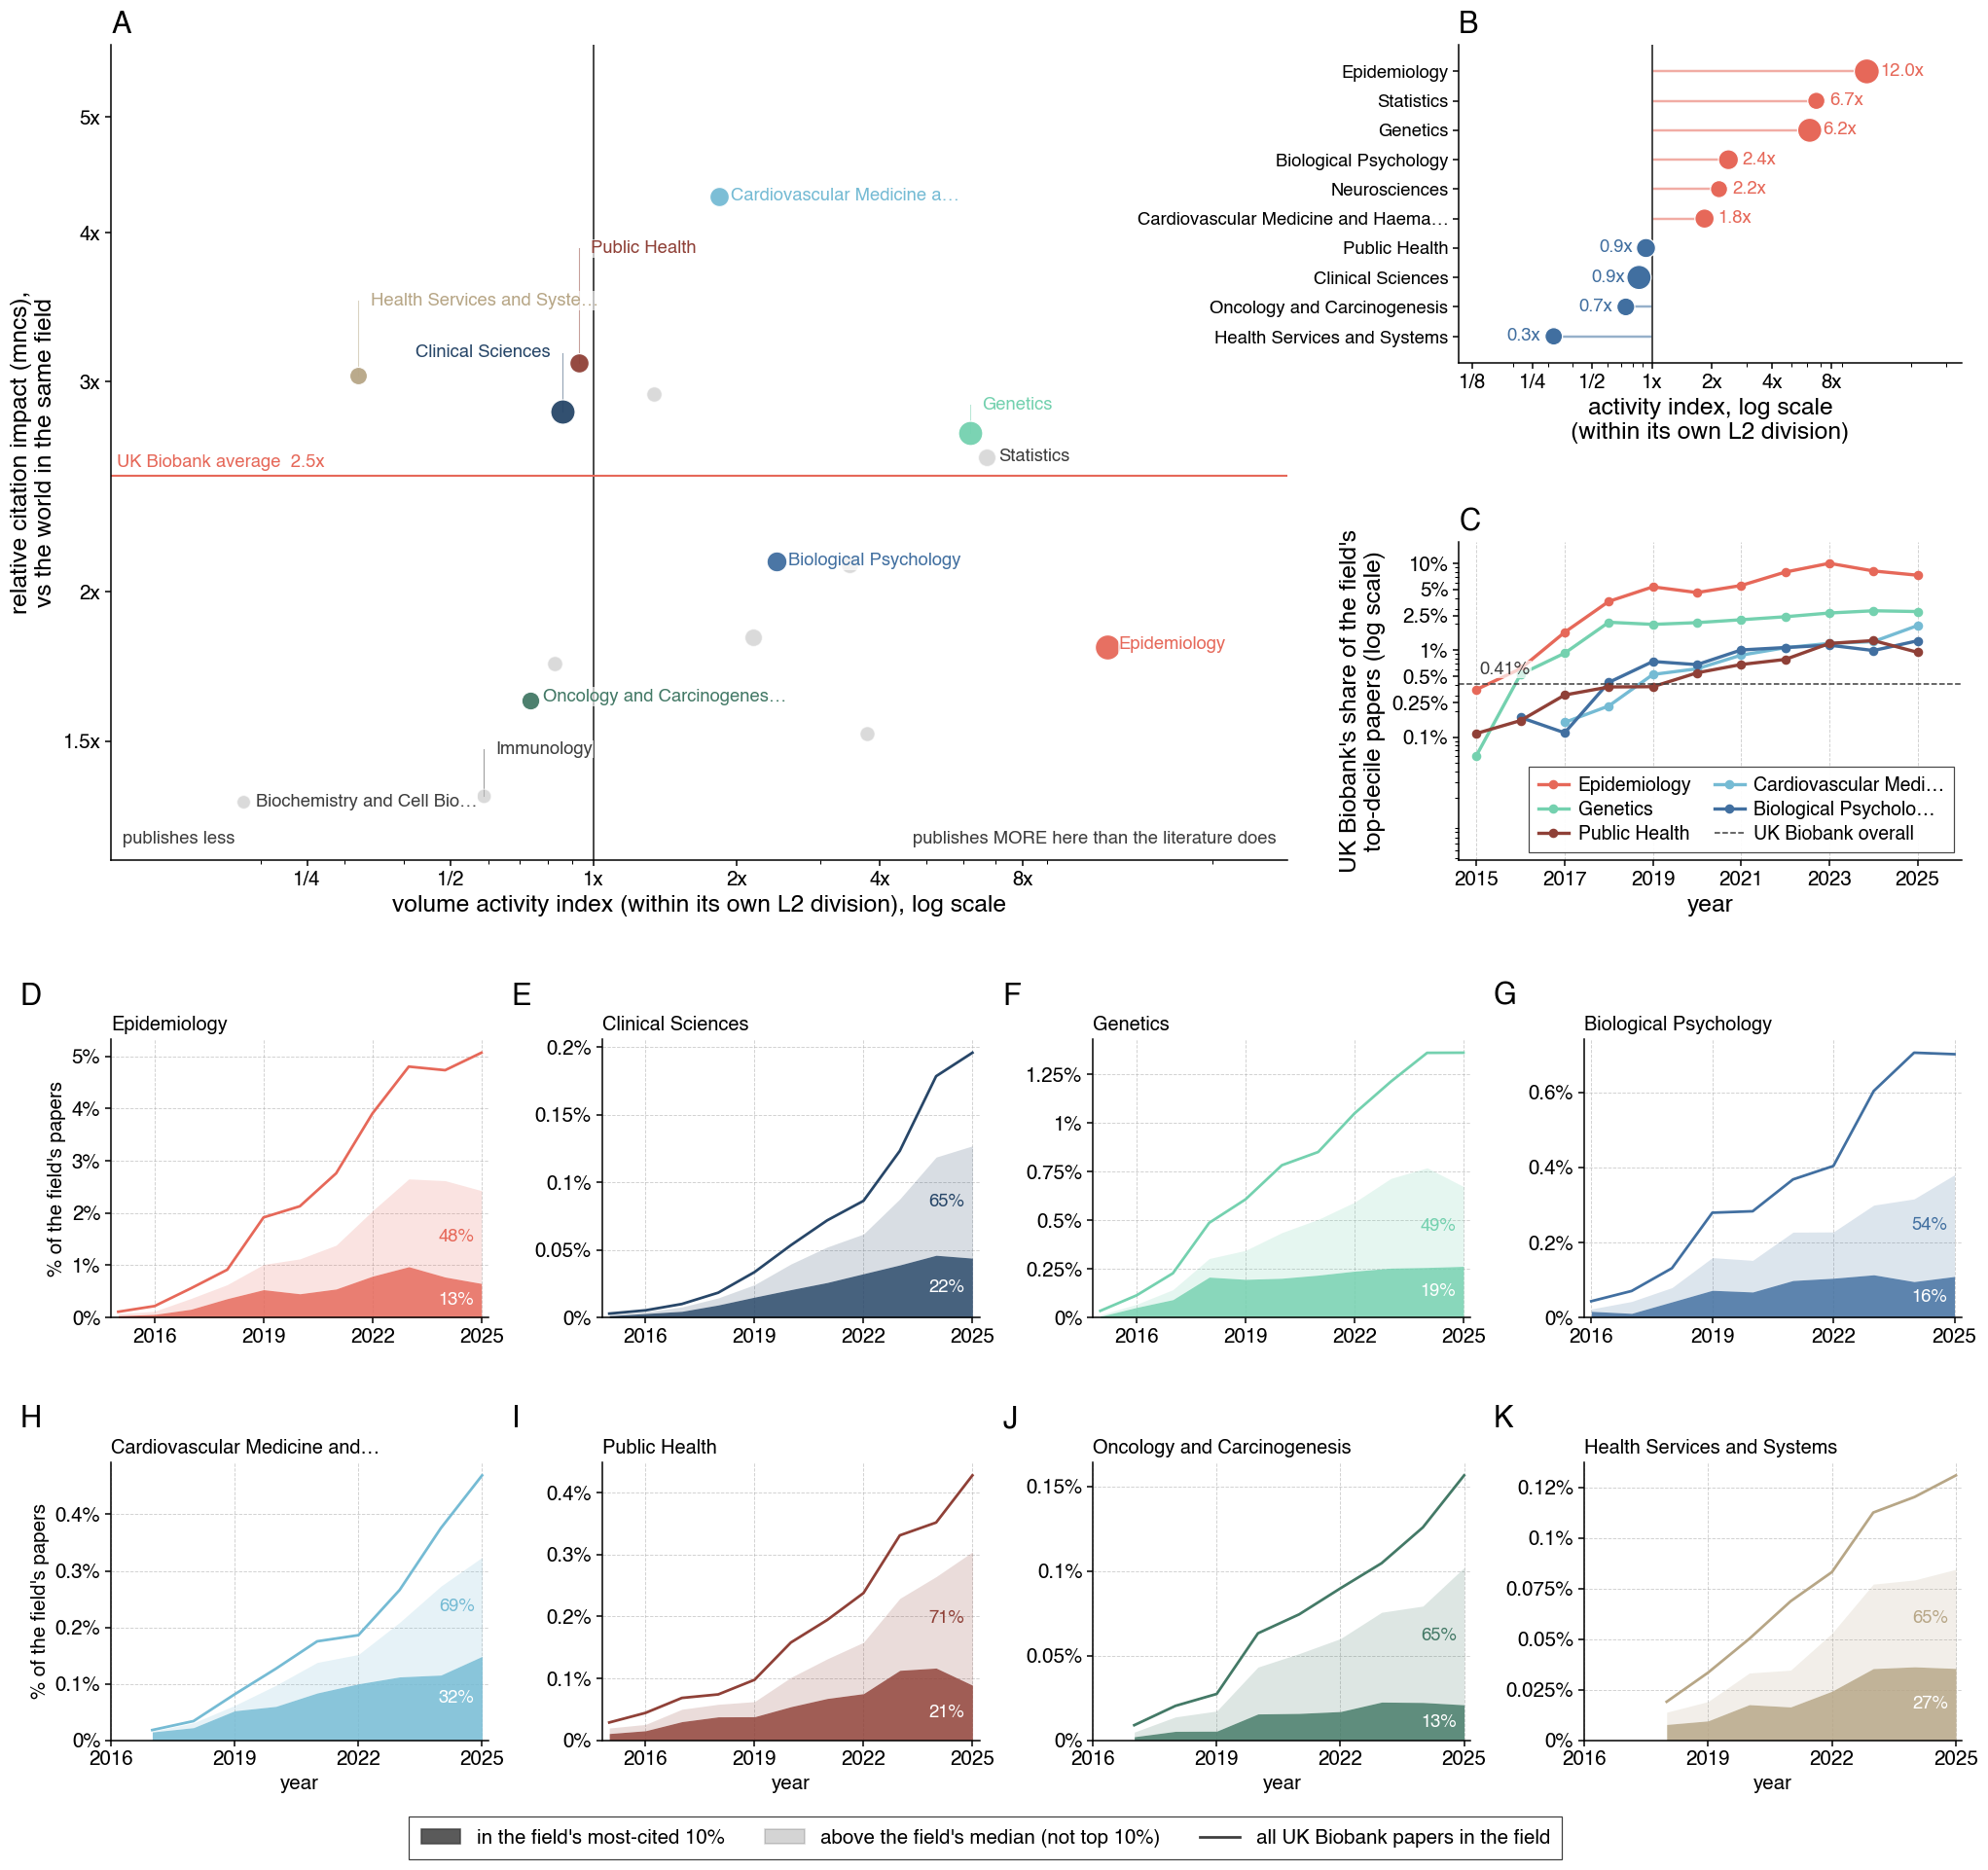

In [6]:
fig_main = NP.figure_main(D)

### 4.1 What panel D's bars were worth, in citations *(for the methods section)*

Panel D cuts each field's footprint at that field's own top decile and median. Both
cut-offs are **measured** per (year, field) by binary search against the live index, not
interpolated — and both fall steeply with publication year because citations accrue:
2015's tenth-best Epidemiology paper needed 63 citations, 2025's needs 8. That is the
clock, not a decline in standards, and it is exactly why the cut is taken per year.

**Read `median_achieved_pct` before quoting a median band.** Citations are small integers
with enormous ties, so in a recent year the cut lands at "≥ 1 citation" and keeps as
little as 34% of the field. The count above the cut is still exact; what is approximate is
calling it the 50th percentile.

The table holds the cells **panel D draws** — the eight fields, inside the window, where
the decile was actually measured. That is a subset of the **213** measured L4 cells across
all 113 fields, over which the decile lands at 7.30–10.00% (median 9.77%) and the median
at 34.23–50.00% (median 47.69%).

In [7]:
cuts = NP.cut_off_table(D)
cuts.to_csv(TABLE_DIR / "panel_d_citation_cutoffs.csv", index=False)
print(f"{len(cuts)} measured (year, field) cells -> "
      f"{P.raw_path(TABLE_DIR / 'panel_d_citation_cutoffs.csv')}\n")

_m = cuts.dropna(subset=["median_achieved_pct"])
print(f"top-decile cut achieved  {cuts.top_decile_cites.notna().sum()} cells")
print(f"median cut achieved      {_m.median_achieved_pct.min():.2f}% - "
      f"{_m.median_achieved_pct.max():.2f}%  (median {_m.median_achieved_pct.median():.2f}%); "
      f"{int((_m.median_achieved_pct < 45).sum())} cells more than five points short\n")

# The final year for each field, which is what the panels' sharp end shows.
display(cuts[cuts.year == NP.ANALYSIS_MAX]
        .set_index("field")[["top_decile_cites", "median_cites", "mean_cites",
                             "median_achieved_pct"]])

81 measured (year, field) cells -> output/tables/03_academic_impact/panel_d_citation_cutoffs.csv

top-decile cut achieved  81 cells
median cut achieved      34.77% - 50.00%  (median 48.13%); 12 cells more than five points short



,top_decile_cites,median_cites,mean_cites,median_achieved_pct
field,,,,
Biological Psychology,7.0,1.0,2.21,49.03
Cardiovascular Medicine and Haematology,5.0,1.0,1.45,34.77
Clinical Sciences,5.0,1.0,1.69,41.76
Epidemiology,8.0,2.0,2.90,39.06
Genetics,7.0,2.0,2.60,38.00
Health Services and Systems,5.0,1.0,1.72,42.34
Oncology and Carcinogenesis,8.0,1.0,2.67,48.24
Public Health,6.0,1.0,2.09,48.44


## 5. SI 1 — The impact map at 25 fields

Main-figure panel A carries UK Biobank's 16 largest fields and labels the top eight plus
whatever is extreme on either axis. This is the same map undrawn-down: 25 fields, every
one labelled, at full page.

**SI 2 is its companion** — the same 25 fields' share of their own top decile, year by
year. Both pages take their field set from `map_fields`, so they cannot disagree about
which 25, and a field's line there can be read straight off its point here. They are two
pages rather than one because two label-dense full-width panels on a single sheet leave
neither of them readable.

The `IMPACT` table beneath the figure is the numbers behind every version of the map, and
it carries **every** weight that takes a ratio rather than only the headline — which is
where the measure-robustness result now lives, chart 6 having been dropped (§3).


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/03_academic_impact/03_02_supplementary_figure_01_impact_map_full.pdf
saved output/figures/data_analysis/03_academic_impact/03_02_supplementary_figure_01_impact_map_full.png
25 fields x 8 measures -> output/tables/03_academic_impact/si1_impact_table_all_weights.csv



,ukbb_papers,activity_x,rci_top10f,act_top10f,rci_top50f,act_top50f,rci_mncs,act_mncs
field,,,,,,,,
Epidemiology,6256.0,12.003,1.965,12.902,1.134,14.367,1.797,44.029
Clinical Sciences,5458.0,0.859,3.118,0.617,1.477,0.563,2.832,2.090
Genetics,5321.0,6.201,2.484,4.774,1.196,4.433,2.719,19.496
Biological Psychology,2244.0,2.420,2.064,1.926,1.104,1.986,2.123,6.854
Cardiovascular Medicine and Haematology,1904.0,1.835,4.302,2.135,1.677,1.605,4.289,6.758
Public Health,1864.0,0.932,3.231,1.647,1.453,1.428,3.111,5.918
Oncology and Carcinogenesis,1359.0,0.738,1.946,0.382,1.370,0.518,1.624,1.029
Health Services and Systems,1207.0,0.320,3.080,0.604,1.392,0.526,3.037,1.985
Statistics,1136.0,6.695,2.088,2.229,1.230,2.532,2.594,8.838


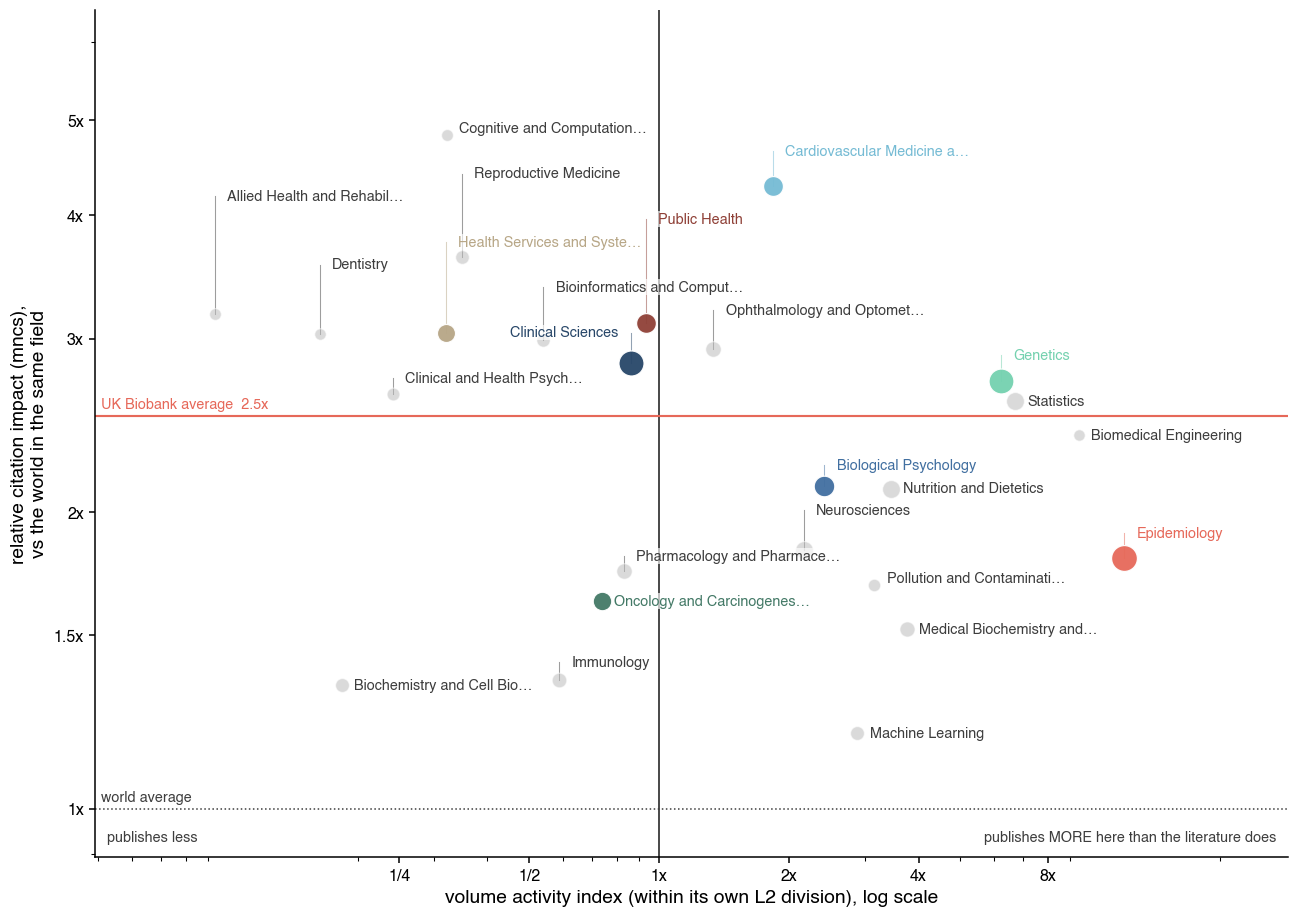

In [8]:
fig_si1 = NP.figure_si_impact_map(D)

# Every rci_ weight, not just the headline: with chart 6 out of the figure set, this
# table is the only place the reader can see whether a field's ranking survives the
# choice of measure.
_cols = ["ukbb_papers", "activity_x"] + [c for c in D["IMPACT"].columns
                                         if c.startswith(("rci_", "act_"))]
impact_out = (D["IMPACT"][_cols]
              .assign(field=[D["label_of"](c) for c in D["IMPACT"].index])
              .set_index("field")
              .nlargest(NP.MAP_M_SI, "ukbb_papers")
              .round(3))
impact_out.to_csv(TABLE_DIR / "si1_impact_table_all_weights.csv")
print(f"{len(impact_out)} fields x {len(_cols)} measures -> "
      f"{P.raw_path(TABLE_DIR / 'si1_impact_table_all_weights.csv')}\n")
display(impact_out)

## 6. SI 2 — The top-decile share at 25 fields

Main-figure panel C is cut to the five fields that reach furthest and read off a legend,
because it has one column of three to live in. This is the same chart at full page with
nothing left implicit: every field SI 1 maps gets its line and its name, the eight the
family follows in their own colours and the other 17 in the map's grey.

It is the panel that carries the analysis's sharpest claim — UK Biobank is 0.044% of the
literature and **7.3%** of Epidemiology's most-cited tenth in 2025 — so the SI shows the
claim's whole surface: which fields clear the overall 0.41% rule, which sit under it, and
how far down the tail the measure stays interpretable at all.


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/03_academic_impact/03_03_supplementary_figure_02_top_decile_share.pdf
saved output/figures/data_analysis/03_academic_impact/03_03_supplementary_figure_02_top_decile_share.png


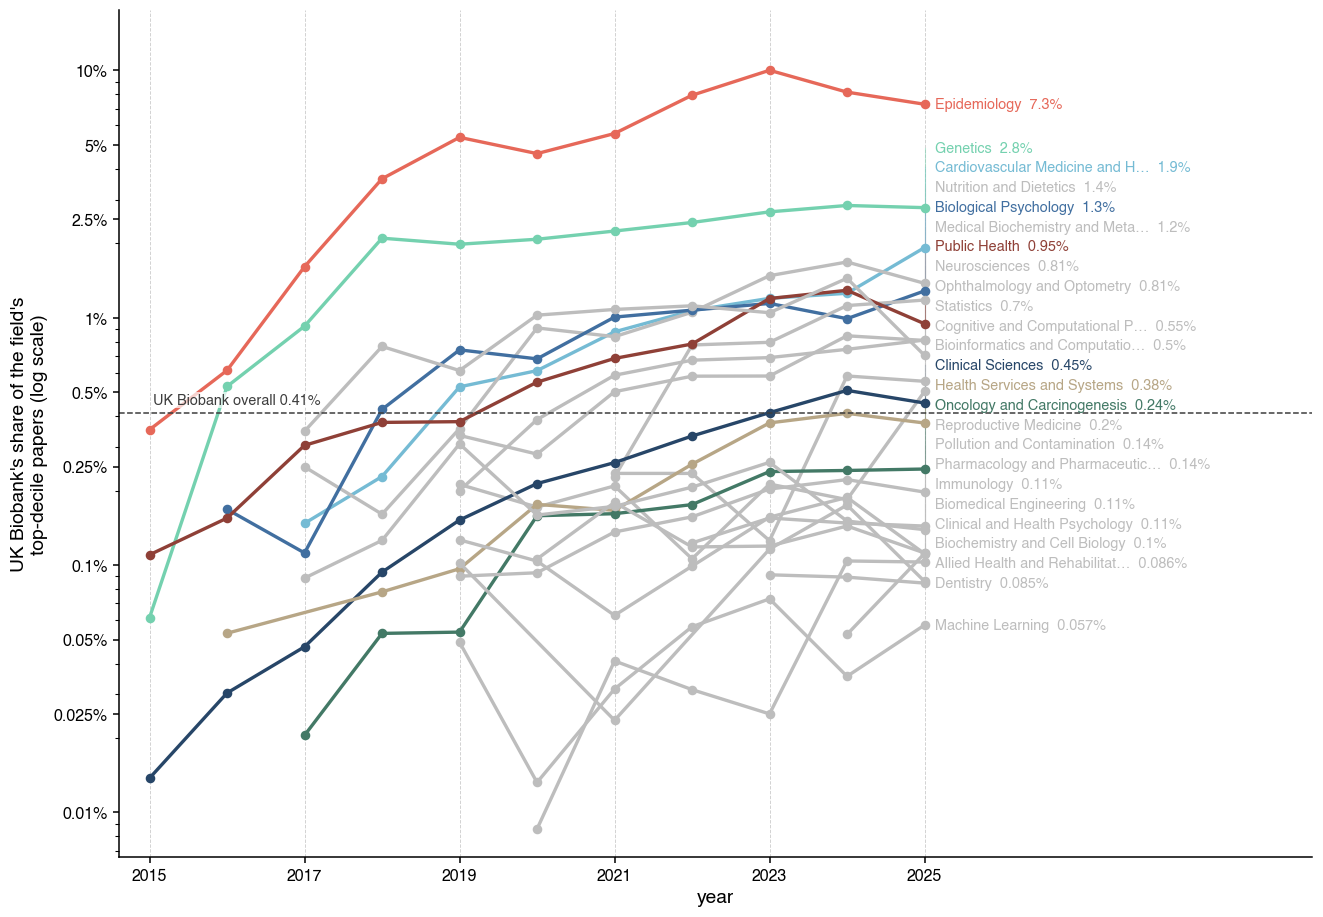

In [9]:
fig_si2 = NP.figure_si_top_decile(D)

## 7. SI 3 — Growth, not size

Every other panel in this family ranks fields by size, which is stable by construction —
Epidemiology and Clinical Sciences were the biggest in 2016 and will be in 2026 — so it
cannot show a field *arriving*. This ranks by speed and drops the size filter.

It is in the SI rather than the main figure because it answers a **growth** question
inside an impact analysis, and analysis 01 owns growth. It is kept because the result is
not available anywhere else: the hollow marker is the same field's growth in the whole
database, so the gap between the markers is UK Biobank **moving into** a field rather than
the field itself taking off. Neurosciences is the sharpest case — the world's output is
flat (−0.2%/yr) while UK Biobank's grows 47%/yr.

Read the acceleration column knowing UK Biobank's own output was doubling annually in the
late 2010s from a base of almost nothing, so nearly every field decelerates against that
window. The number says "growing less explosively than during the ramp-up", not
"shrinking".

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


saved output/figures/data_analysis/03_academic_impact/03_04_supplementary_figure_03_growth.pdf
saved output/figures/data_analysis/03_academic_impact/03_04_supplementary_figure_03_growth.png
UK Biobank overall grew 26%/yr over 2021-2025



,ukbb@2025,ukbb_%/yr,ukbb_accel_pp,world_%/yr,activity_x
label,,,,,
Medical Biochemistry and Metabolomics,200.0,73.6,-8.5,12.6,3.8
Biomedical Engineering,35.0,62.7,13.1,7.4,9.4
Biochemistry and Cell Biology,112.0,57.9,NaN,2.2,0.2
Clinical and Health Psychology,49.0,42.2,23.2,6.2,0.2
Neurosciences,329.0,39.9,-54.7,2.2,2.2
Cognitive and Computational Psychology,39.0,37.2,-15.9,5.1,0.3
Ophthalmology and Optometry,159.0,37.1,-46.0,2.4,1.3
Nutrition and Dietetics,308.0,34.9,-18.0,6.0,3.4
Bioinformatics and Computational Biology,66.0,34.8,-43.0,0.9,0.5


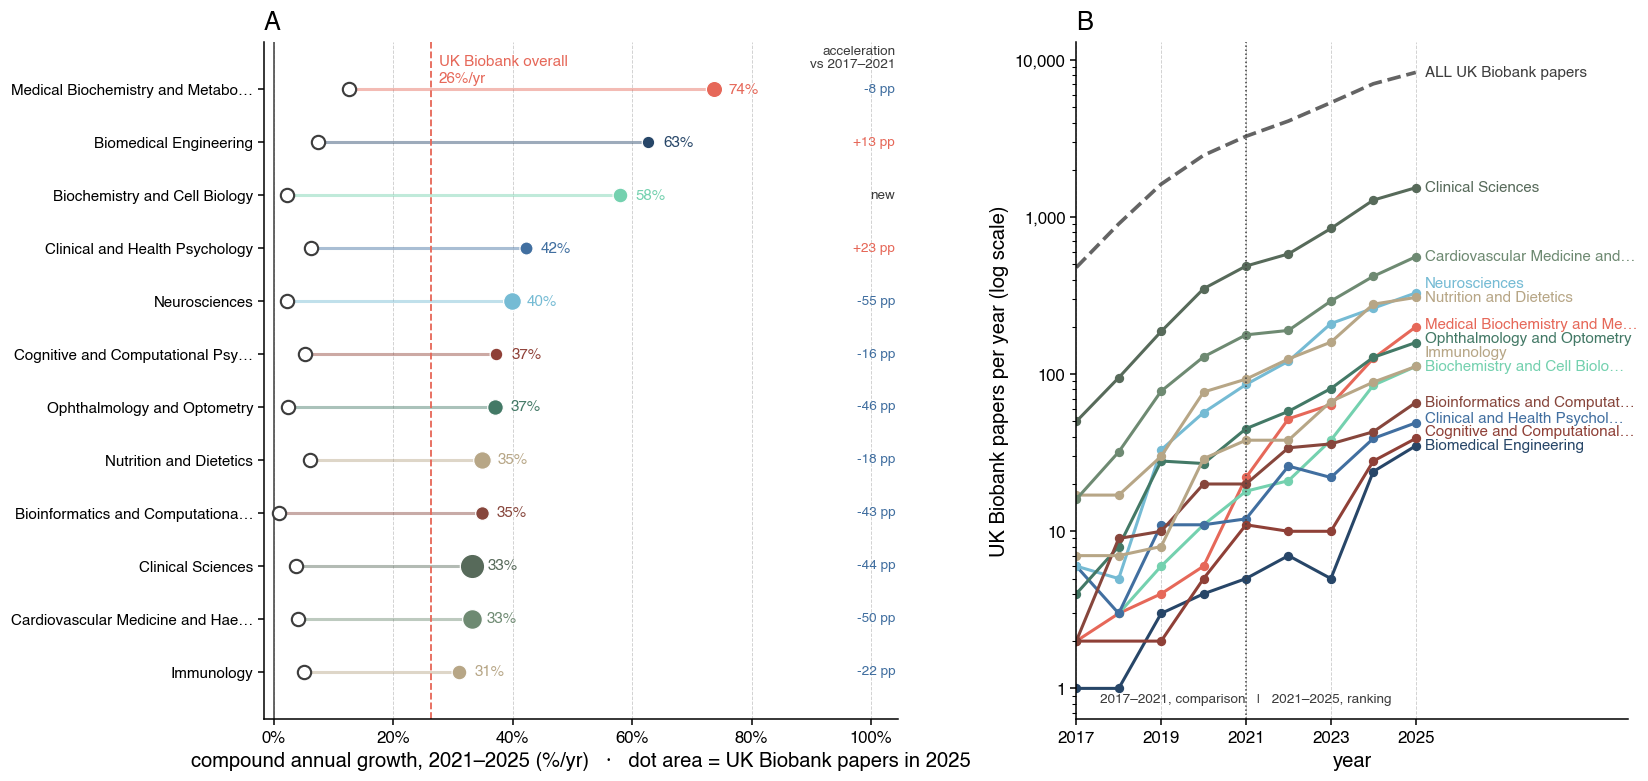

In [10]:
fig_si3 = NP.figure_si_growth(D)

growth_out = (D["GROWTH"].head(NP.GROW_TOP_M)
              .set_index("label")[["ukbb_papers", "ukbb_now", "accel",
                                   "world_now", "activity_x"]]
              .rename(columns={"ukbb_papers": f"ukbb@{NP.GROW_NOW[1]}",
                               "ukbb_now": "ukbb_%/yr", "accel": "ukbb_accel_pp",
                               "world_now": "world_%/yr"})
              .round(1))
growth_out.to_csv(TABLE_DIR / "si2_fastest_growing_fields.csv")
print(f"UK Biobank overall grew {D['UKBB_PACE']:.0f}%/yr over "
      f"{NP.GROW_NOW[0]}-{NP.GROW_NOW[1]}\n")
display(growth_out)

## 8. What was written

Every file this notebook produced, with its size, so a re-run can be compared against the
last one rather than trusted. **pdf and png only** — svg was dropped from every style
section on 2026-09-09 (the author-arm portfolio panel alone was an 8 MB svg, because each
of its 11,022 authors became its own element) and svg files are gitignored. The glob
follows D30's naming scheme, so the author notebook's own three figures — which sit in the
same directory under their `fig…` stems — are correctly not listed here, and neither is
`03_04_supplementary_figure_03_author_arm`, which this notebook no longer writes.

In [11]:
written = sorted(
    p for p in FIG_DIR.glob("03_[0-9][0-9]_*.*")
    if p.suffix.lower() in {".pdf", ".png"}
)
manifest = pd.DataFrame([
    {"file": P.raw_path(p), "kb": p.stat().st_size // 1024,
     "modified": pd.Timestamp(p.stat().st_mtime, unit="s").round("s")}
    for p in written
])
manifest.to_csv(TABLE_DIR / "panel_manifest.csv", index=False)
print(f"{len(written)} figure files under {P.raw_path(FIG_DIR)} "
      f"({manifest.kb.sum() / 1024:.1f} MB)\n")
display(manifest)

8 figure files under output/figures/data_analysis/03_academic_impact (7.3 MB)



,file,kb,modified
0,output/figures/data_analysis/03_academic_impac...,36,2026-09-19 04:55:41
1,output/figures/data_analysis/03_academic_impac...,3213,2026-09-19 04:55:44
2,output/figures/data_analysis/03_academic_impac...,23,2026-09-19 04:55:45
3,output/figures/data_analysis/03_academic_impac...,807,2026-09-19 04:55:46
4,output/figures/data_analysis/03_academic_impac...,29,2026-09-19 04:55:46
5,output/figures/data_analysis/03_academic_impac...,1695,2026-09-19 04:55:48
6,output/figures/data_analysis/03_academic_impac...,29,2026-09-19 04:55:48
7,output/figures/data_analysis/03_academic_impac...,1623,2026-09-19 04:55:49
